In [666]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BicScore
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os

In [667]:
import pandas as pd

# Load the Excel file into a DataFrame
file_path = 'Long_COVID_Dataset_AIIMS_BBSR (1).xlsx'
lc1 = pd.read_excel(file_path, sheet_name='Follow-up at 4 weeks')  # Replace 'Sheet1' with the actual sheet name
lc2=pd.read_excel(file_path, sheet_name='Follow-up at 6 months')


In [668]:
lc1['participant_id'] = lc1['participant_id'].str.upper()
lc2['participant_id'] = lc2['participant_id'].str.upper()

In [669]:
merged_lc= pd.merge(lc1, lc2, on='participant_id', how='outer')

In [670]:
merged_lc.head(5)

,participant_id,date_diff_four,age,sex,education,occupation,occupation_covid,height,weight,substance_use,smoking,tobacco,alcohol,drugs,past_history_covid,diabetes,hypertension,anxiety,depression,asthma,tb,cancer,other_medical,vaccine_dose_four,vaccine_type_four,vaccine_aefi_four,acute_symptoms,acute_symptoms_count,ct_egene_ngene,ct_orf1a_b_n2gene,covid_severity,covid_care,longcovid_four,lc_fatigue_four,lc_cough_four,lc_headache_four,lc_breathing_four,lc_taste_four,lc_smell_four,lc_brainfog_four,lc_chestpain_four,lc_palpitation_four,lc_anxiety_four,lc_depression_four,lc_fever_four,lc_other_four,lc_activitylimit_four,lc_consultation_four,lc_hospitalized_four,date_diff_six,vaccine_add_dose_six,vaccine_add_dose_type_six,new_acute_covid_six,new_acute_covid_severity_six,new_medical_diag_six,longcovid_six,lc_fatigue_six,lc_cough_six,lc_headache_six,lc_breathing_six,lc_taste_six,lc_smell_six,lc_brainfog_six,lc_chestpain_six,lc_palpitations_six,lc_anxiety_six,lc_depression_six,lc_fever_six,lc_other_six,lc_activitylimit_six,lc_consultation_six,lc_hospitalized_six
0,LC001,42,29,Male,Post graduation & above,Professional / Technical / Administrative / Ma...,No,167.0,67.0,No,NaN,NaN,NaN,NaN,Yes,No,No,No,No,No,No,No,NaN,Yes - Two doses,Covaxin,Yes - Mild,"Fever, Cough, Bodyache, Breathing difficulty, ...",6,30,29,Mild/Moderate - Did not receive oxygen,Home isolation,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,234.0,No,NaN,No,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LC002,42,35,Male,Post graduation & above,Professional / Technical / Administrative / Ma...,No,165.0,80.0,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,NaN,Yes - Two doses,Covaxin,No,"Loss of smell, Loss of taste",2,NaN,NaN,Mild/Moderate - Did not receive oxygen,Home isolation,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LC003,42,22,Female,College graduate,Unemployed / Student / Homemaker,No,162.0,53.0,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,NaN,Yes - Two doses,Covaxin,No,Cold,1,23,NaN,Mild/Moderate - Did not receive oxygen,Home isolation,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.0,No,NaN,No,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LC004,42,23,Female,College graduate,Professional / Technical / Administrative / Ma...,Yes,153.0,60.0,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,NaN,Yes - Two doses,Covaxin,No,"Sore throat, Fever, Tiredness, Bodyache, Loss ...",5,26,NaN,Mild/Moderate - Did not receive oxygen,Home isolation,YES - Not severe,Yes,Yes,No,No,No,No,No,No,No,No,No,No,Yes,No activity limitation,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LC005,43,22,Female,10th standard or below,Unemployed / Student / Homemaker,No,142.0,50.0,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,NaN,Yes - Only first dose,Covaxin,No,NO SYMPTOMS,0,32,32,Mild/Moderate - Did not receive oxygen,Home isolation,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.0,Yes - Second dose,Covishield,No,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [671]:
merged_lc.shape

(487, 72)

In [672]:
merged_lc.isna().sum()

participant_id                    0
date_diff_four                    0
age                               0
sex                               0
education                         0
occupation                        0
occupation_covid                  0
height                            3
weight                            3
substance_use                     0
smoking                         433
tobacco                         433
alcohol                         433
drugs                           433
past_history_covid                0
diabetes                          0
hypertension                      0
anxiety                           0
depression                        0
asthma                            0
tb                                0
cancer                            0
other_medical                   434
vaccine_dose_four                 0
vaccine_type_four               119
vaccine_aefi_four               119
acute_symptoms                    0
acute_symptoms_count        

Extraction of columns from Acute_symptoms

In [673]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)

In [674]:
# Create a DataFrame with binary encoding for the presence of each value
binary_comments =merged_lc['acute_symptoms'].str.get_dummies(sep=',')

In [675]:
#deleting spaces before column names
binary_comments.columns = [col.lstrip() for col in binary_comments.columns]
#checking stats
#binary_comments.sum().sort_values(ascending=False)

In [676]:
binary_comments = binary_comments.sort_index(axis=1)
binary_comments.head(2)

,Bodyache,Bodyache,Breathing difficulty,Breathing difficulty,Cold,Constipation,Cough,Cough,Diarrhoea,Diarrhoea,Diarrhoea,Fever,Fever,Headache,Headache,Headache reeling,Loss of smell,Loss of smell,Loss of taste,Loss of taste,NO SYMPTOMS,Nasal congestion,Nasal congestion,Nasal congestion,Retro orbital pain,Running nose,Running nose,Sneezing,Sore throat,Sore throat,Sudden collapse,Tiredness,Tiredness,Vomiting,Vomiting,Wheezing,blood in stools,chest pain,cold,headache,headache,headche,headreeling,hoarseness of voice,loss of appetite,pain in eyes,vomiting
0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [677]:
headache_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'Head' in col_name]
binary_comments['Headache'] = binary_comments.iloc[:, headache_cols].any(axis=1).astype(int)

# Delete the columns compared
#binary_comments.drop(binary_comments.columns[headache_cols], axis=1, inplace=True)


In [678]:
binary_comments.head(2)

,Bodyache,Bodyache,Breathing difficulty,Breathing difficulty,Cold,Constipation,Cough,Cough,Diarrhoea,Diarrhoea,Diarrhoea,Fever,Fever,Headache,Headache,Headache reeling,Loss of smell,Loss of smell,Loss of taste,Loss of taste,NO SYMPTOMS,Nasal congestion,Nasal congestion,Nasal congestion,Retro orbital pain,Running nose,Running nose,Sneezing,Sore throat,Sore throat,Sudden collapse,Tiredness,Tiredness,Vomiting,Vomiting,Wheezing,blood in stools,chest pain,cold,headache,headache,headche,headreeling,hoarseness of voice,loss of appetite,pain in eyes,vomiting
0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [679]:
headache_cols2 = [i for i, col_name in enumerate(binary_comments.columns) if 'head' in col_name]
binary_comments['headache'].sum()

#Delete the columns compared
#binary_comments.drop(binary_comments.columns[headache_cols2], axis=1, inplace=True)

headache    1
headache    2
dtype: int64

In [680]:
binary_comments.columns

Index(['Bodyache', 'Bodyache', 'Breathing difficulty', 'Breathing difficulty',
       'Cold', 'Constipation', 'Cough', 'Cough', 'Diarrhoea', 'Diarrhoea ',
       'Diarrhoea ', 'Fever', 'Fever', 'Headache', 'Headache',
       'Headache reeling', 'Loss of smell', 'Loss of smell', 'Loss of taste',
       'Loss of taste', 'NO SYMPTOMS ', 'Nasal congestion',
       'Nasal congestion ', 'Nasal congestion ', 'Retro orbital pain',
       'Running nose', 'Running nose', 'Sneezing', 'Sore throat',
       'Sore throat', 'Sudden collapse', 'Tiredness', 'Tiredness', 'Vomiting',
       'Vomiting', 'Wheezing ', 'blood in stools', 'chest pain', 'cold',
       'headache', 'headache', 'headche', 'headreeling', 'hoarseness of voice',
       'loss of appetite', 'pain in eyes', 'vomiting'],
      dtype='object')

In [681]:
drop_this=['Headache reeling','NO SYMPTOMS ','headreeling','headche']
binary_comments=binary_comments.drop(columns=drop_this)

In [682]:
binary_comments.columns

Index(['Bodyache', 'Bodyache', 'Breathing difficulty', 'Breathing difficulty',
       'Cold', 'Constipation', 'Cough', 'Cough', 'Diarrhoea', 'Diarrhoea ',
       'Diarrhoea ', 'Fever', 'Fever', 'Headache', 'Headache', 'Loss of smell',
       'Loss of smell', 'Loss of taste', 'Loss of taste', 'Nasal congestion',
       'Nasal congestion ', 'Nasal congestion ', 'Retro orbital pain',
       'Running nose', 'Running nose', 'Sneezing', 'Sore throat',
       'Sore throat', 'Sudden collapse', 'Tiredness', 'Tiredness', 'Vomiting',
       'Vomiting', 'Wheezing ', 'blood in stools', 'chest pain', 'cold',
       'headache', 'headache', 'hoarseness of voice', 'loss of appetite',
       'pain in eyes', 'vomiting'],
      dtype='object')

In [683]:
binary_comments1 = pd.DataFrame()

# Iterate through the unique column names
unique_columns = binary_comments.columns.unique()
for col in unique_columns:
    # Filter columns with the same name
    cols_with_same_name = [c for c in binary_comments.columns if c == col]
    
    # Use the bitwise OR operation to combine columns with the same name
    combined_col = binary_comments[cols_with_same_name].max(axis=1)
    
    # Store the combined column in the new DataFrame
    binary_comments1[col] = combined_col

# Resulting DataFrame will have the combined columns
binary_comments1.head(1)

,Bodyache,Breathing difficulty,Cold,Constipation,Cough,Diarrhoea,Diarrhoea,Fever,Headache,Loss of smell,Loss of taste,Nasal congestion,Nasal congestion,Retro orbital pain,Running nose,Sneezing,Sore throat,Sudden collapse,Tiredness,Vomiting,Wheezing,blood in stools,chest pain,cold,headache,hoarseness of voice,loss of appetite,pain in eyes,vomiting
0,1,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [684]:
binary_comments1['Diarrhoea1'] = binary_comments1[['Diarrhoea', 'Diarrhoea']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['Diarrhoea','Diarrhoea']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [685]:
binary_comments1['Nasal congestion1'] = binary_comments1[['Nasal congestion', 'Nasal congestion']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['Nasal congestion','Nasal congestion']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [686]:
binary_comments1['Cold1'] = binary_comments1[['cold', 'Cold']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['cold','Cold']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [687]:
binary_comments1['Headache1'] = binary_comments1[['headache', 'Headache']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['headache','Headache']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [688]:
binary_comments1.columns

Index(['Bodyache', 'Breathing difficulty', 'Constipation', 'Cough',
       'Diarrhoea ', 'Fever', 'Loss of smell', 'Loss of taste',
       'Nasal congestion ', 'Retro orbital pain', 'Running nose', 'Sneezing',
       'Sore throat', 'Sudden collapse', 'Tiredness', 'Vomiting', 'Wheezing ',
       'blood in stools', 'chest pain', 'hoarseness of voice',
       'loss of appetite', 'pain in eyes', 'vomiting', 'Diarrhoea1',
       'Nasal congestion1', 'Cold1', 'Headache1'],
      dtype='object')

In [689]:
binary_comments1.isna().sum()

Bodyache                0
Breathing difficulty    0
Constipation            0
Cough                   0
Diarrhoea               0
Fever                   0
Loss of smell           0
Loss of taste           0
Nasal congestion        0
Retro orbital pain      0
Running nose            0
Sneezing                0
Sore throat             0
Sudden collapse         0
Tiredness               0
Vomiting                0
Wheezing                0
blood in stools         0
chest pain              0
hoarseness of voice     0
loss of appetite        0
pain in eyes            0
vomiting                0
Diarrhoea1              0
Nasal congestion1       0
Cold1                   0
Headache1               0
dtype: int64

In [690]:
merged_lc.columns

Index(['participant_id', 'date_diff_four', 'age', 'sex', 'education',
       'occupation', 'occupation_covid', 'height', 'weight', 'substance_use',
       'smoking', 'tobacco', 'alcohol', 'drugs', 'past_history_covid',
       'diabetes', 'hypertension', 'anxiety', 'depression', 'asthma', 'tb',
       'cancer', 'other_medical', 'vaccine_dose_four', 'vaccine_type_four',
       'vaccine_aefi_four', 'acute_symptoms', 'acute_symptoms_count',
       'ct_egene_ngene', 'ct_orf1a_b_n2gene', 'covid_severity', 'covid_care',
       'longcovid_four', 'lc_fatigue_four', 'lc_cough_four',
       'lc_headache_four', 'lc_breathing_four', 'lc_taste_four',
       'lc_smell_four', 'lc_brainfog_four', 'lc_chestpain_four',
       'lc_palpitation_four', 'lc_anxiety_four', 'lc_depression_four',
       'lc_fever_four', 'lc_other_four', 'lc_activitylimit_four',
       'lc_consultation_four', 'lc_hospitalized_four', 'date_diff_six',
       'vaccine_add_dose_six', 'vaccine_add_dose_type_six',
       'new_acute_cov

In [691]:
merged_lc=pd.merge(merged_lc, binary_comments1, how='outer', left_index=True, right_index=True, suffixes=('_initial', '_comment'))

In [692]:
merged_lc.columns

Index(['participant_id', 'date_diff_four', 'age', 'sex', 'education',
       'occupation', 'occupation_covid', 'height', 'weight', 'substance_use',
       'smoking', 'tobacco', 'alcohol', 'drugs', 'past_history_covid',
       'diabetes', 'hypertension', 'anxiety', 'depression', 'asthma', 'tb',
       'cancer', 'other_medical', 'vaccine_dose_four', 'vaccine_type_four',
       'vaccine_aefi_four', 'acute_symptoms', 'acute_symptoms_count',
       'ct_egene_ngene', 'ct_orf1a_b_n2gene', 'covid_severity', 'covid_care',
       'longcovid_four', 'lc_fatigue_four', 'lc_cough_four',
       'lc_headache_four', 'lc_breathing_four', 'lc_taste_four',
       'lc_smell_four', 'lc_brainfog_four', 'lc_chestpain_four',
       'lc_palpitation_four', 'lc_anxiety_four', 'lc_depression_four',
       'lc_fever_four', 'lc_other_four', 'lc_activitylimit_four',
       'lc_consultation_four', 'lc_hospitalized_four', 'date_diff_six',
       'vaccine_add_dose_six', 'vaccine_add_dose_type_six',
       'new_acute_cov

In [693]:
merged_lc['vaccine_type_four'].fillna('None', inplace=True)

In [694]:
longcovid_1=merged_lc.loc[:,['age','education','longcovid_four', 'sex', 'occupation_covid', 'substance_use', 'covid_severity', 'covid_care', 'past_history_covid', 'diabetes', 
                               'hypertension', 'asthma', 'cancer','vaccine_type_four', 'vaccine_dose_four','Cold1','vaccine_aefi_four','Cough', 'Breathing difficulty', 'Sore throat',
                               'Headache1', 'Loss of smell', 'Loss of taste', 'Fever', 'Diarrhoea1','vaccine_add_dose_six','vaccine_add_dose_type_six','substance_use',
                               'new_acute_covid_six','new_acute_covid_severity_six','new_medical_diag_six','longcovid_six','lc_fatigue_six','lc_cough_six','lc_headache_six','lc_breathing_six',
                               'lc_taste_six','lc_smell_six','lc_chestpain_six','lc_fever_six','lc_hospitalized_six'
                              ]]

In [695]:
#Age ranges
age_groups = {
   
    range(13, 25): 0,
    range(25, 45): 1,
    range(45, 66): 2,
    range(66, 120): 3
}

# encode the age column
longcovid_1['Age_group'] =longcovid_1['age'].map(lambda Age: next((a for b, a in age_groups.items() if Age in b), None))

In [696]:
under = longcovid_1[[ 'diabetes', 'hypertension', 'asthma', 'cancer']].any(axis=1).astype(int)
longcovid_1['under_cond'] = under

In [697]:
longcovid_1.head(3)

,age,education,longcovid_four,sex,occupation_covid,substance_use,covid_severity,covid_care,past_history_covid,diabetes,hypertension,asthma,cancer,vaccine_type_four,vaccine_dose_four,Cold1,vaccine_aefi_four,Cough,Breathing difficulty,Sore throat,Headache1,Loss of smell,Loss of taste,Fever,Diarrhoea1,vaccine_add_dose_six,vaccine_add_dose_type_six,substance_use,new_acute_covid_six,new_acute_covid_severity_six,new_medical_diag_six,longcovid_six,lc_fatigue_six,lc_cough_six,lc_headache_six,lc_breathing_six,lc_taste_six,lc_smell_six,lc_chestpain_six,lc_fever_six,lc_hospitalized_six,Age_group,under_cond
0,29,Post graduation & above,NO (End of Data Collection),Male,No,No,Mild/Moderate - Did not receive oxygen,Home isolation,Yes,No,No,No,No,Covaxin,Yes - Two doses,0,Yes - Mild,1,1,0,0,1,0,1,0,No,NaN,No,No,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,35,Post graduation & above,NO (End of Data Collection),Male,No,No,Mild/Moderate - Did not receive oxygen,Home isolation,No,No,No,No,No,Covaxin,Yes - Two doses,0,No,0,0,0,0,1,1,0,0,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,22,College graduate,NO (End of Data Collection),Female,No,No,Mild/Moderate - Did not receive oxygen,Home isolation,No,No,No,No,No,Covaxin,Yes - Two doses,1,No,0,0,0,0,0,0,0,0,No,NaN,No,No,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


In [698]:
longcovid_1.var()

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_28921/3716295709.py:1: FutureWarning: The default value of numeric_only in DataFrame.var is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  longcovid_1.var()


age                     227.595880
Cold1                     0.014196
Cough                     0.248375
Breathing difficulty      0.134788
Sore throat               0.092318
Headache1                 0.029914
Loss of smell             0.114381
Loss of taste             0.115894
Fever                     0.228306
Diarrhoea1                0.002053
Age_group                 0.664461
under_cond                0.000000
dtype: float64

In [699]:
longcovid_1.isna().sum()

age                               0
education                         0
longcovid_four                    0
sex                               0
occupation_covid                  0
substance_use                     0
covid_severity                    0
covid_care                        0
past_history_covid                0
diabetes                          0
hypertension                      0
asthma                            0
cancer                            0
vaccine_type_four                 0
vaccine_dose_four                 0
Cold1                             0
vaccine_aefi_four               119
Cough                             0
Breathing difficulty              0
Sore throat                       0
Headache1                         0
Loss of smell                     0
Loss of taste                     0
Fever                             0
Diarrhoea1                        0
vaccine_add_dose_six            116
vaccine_add_dose_type_six       336
substance_use               

In [700]:
longcovid_1.head(3)

,age,education,longcovid_four,sex,occupation_covid,substance_use,covid_severity,covid_care,past_history_covid,diabetes,hypertension,asthma,cancer,vaccine_type_four,vaccine_dose_four,Cold1,vaccine_aefi_four,Cough,Breathing difficulty,Sore throat,Headache1,Loss of smell,Loss of taste,Fever,Diarrhoea1,vaccine_add_dose_six,vaccine_add_dose_type_six,substance_use,new_acute_covid_six,new_acute_covid_severity_six,new_medical_diag_six,longcovid_six,lc_fatigue_six,lc_cough_six,lc_headache_six,lc_breathing_six,lc_taste_six,lc_smell_six,lc_chestpain_six,lc_fever_six,lc_hospitalized_six,Age_group,under_cond
0,29,Post graduation & above,NO (End of Data Collection),Male,No,No,Mild/Moderate - Did not receive oxygen,Home isolation,Yes,No,No,No,No,Covaxin,Yes - Two doses,0,Yes - Mild,1,1,0,0,1,0,1,0,No,NaN,No,No,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,35,Post graduation & above,NO (End of Data Collection),Male,No,No,Mild/Moderate - Did not receive oxygen,Home isolation,No,No,No,No,No,Covaxin,Yes - Two doses,0,No,0,0,0,0,1,1,0,0,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,22,College graduate,NO (End of Data Collection),Female,No,No,Mild/Moderate - Did not receive oxygen,Home isolation,No,No,No,No,No,Covaxin,Yes - Two doses,1,No,0,0,0,0,0,0,0,0,No,NaN,No,No,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


In [701]:
#tried mapping a few items for the covid 6 before we continue with mapping we should know how to deal with all nans

In [702]:
type(longcovid_1['substance_use'])

pandas.core.frame.DataFrame

In [703]:
longcovid_1['substance_use'].isna().sum()

substance_use    0
substance_use    0
dtype: int64

In [704]:
longcovid_1['Diarrhoea1'].value_counts()

0    486
1      1
Name: Diarrhoea1, dtype: int64

In [705]:
# Define mapping dictionaries for each categorical variable



gender_mapping = {'Female': 0, 'Male': 1}
diabetes_mapping = {'No': 0, 'Yes': 1}
hypertension_mapping = {'No': 0, 'Yes': 1}

asthma_mapping = {'No': 0, 'Yes': 1}

cancer_mapping = {'No': 0, 'Yes': 1}
vaccine_type_mapping = {'None':0,'Covaxin': 1, 'Covishield': 2}
education_mapping = {
    'Post graduation & above': 0,
    'College graduate': 1,
    '10th standard or below': 2,
    'Higher Secondary (11 to 12th standard)': 3,
    'Illiterate / No formal schooling': 4
}
occupation_covid_mapping = {'No': 0, 'Yes': 1}
past_history_covid_mapping = {'No': 0, 'Yes': 1}
covid_severity_mapping = {
    'Mild/Moderate - Did not receive oxygen': 0,
    'Severe - Received oxygen or was told you require oxygen': 1,
    'Critical - Received invasive ventilation': 2
}
longcovid_four_mapping = {'NO (End of Data Collection)': 0, 'YES - Not severe': 1, 'YES - Severe': 2}
vaccine_dose_four_mapping = {'Yes - Two doses': 2, 'Yes - Only first dose': 1, 'No': 0}
covid_care_mapping = {'Home isolation': 0, 'Admitted to hospital': 1}
vaccine_aefi_four_mapping = {'Yes - Mild': 0, 'No': 1, 'Yes - Moderate - Consulted a doctor': 2, 'Yes - Severe and Hospital admission': 3}
#substance_use_mapping = {'No':0,'Yes':1}

vaccine_add_dose_six_mapping={'No':0,'Yes - Second dose':1,'Yes - Precaution dose':2,'Yes - First dose':3}
vaccine_add_dose_type_six_mapping={'Covaxin':0,'Covishield':1}
new_acute_covid_six_mapping={'No':0,'Yes':1}
new_acute_covid_six_mapping={'No':0,'Yes':1}
new_acute_covid_six_mapping={'No':0,'Yes':1}


# Apply mapping to the respective columns
longcovid_1['sex'] = longcovid_1['sex'].map(gender_mapping)

longcovid_1['hypertension'] = longcovid_1['hypertension'].map(hypertension_mapping)


longcovid_1['asthma'] = longcovid_1['asthma'].map(asthma_mapping)

longcovid_1['cancer'] = longcovid_1['cancer'].map(cancer_mapping)
longcovid_1['vaccine_type_four'] = longcovid_1['vaccine_type_four'].map(vaccine_type_mapping)
longcovid_1['education'] = longcovid_1['education'].map(education_mapping)
longcovid_1['occupation_covid'] = longcovid_1['occupation_covid'].map(occupation_covid_mapping)
longcovid_1['past_history_covid'] = longcovid_1['past_history_covid'].map(past_history_covid_mapping)
longcovid_1['covid_severity'] = longcovid_1['covid_severity'].map(covid_severity_mapping)
longcovid_1['longcovid_four'] = longcovid_1['longcovid_four'].map(longcovid_four_mapping)
longcovid_1['vaccine_dose_four'] = longcovid_1['vaccine_dose_four'].map(vaccine_dose_four_mapping)
longcovid_1['covid_care'] = longcovid_1['covid_care'].map(covid_care_mapping)
longcovid_1['vaccine_aefi_four'] = longcovid_1['vaccine_aefi_four'].map(vaccine_aefi_four_mapping)
#longcovid_1['substance_use'] = longcovid_1['substance_use'].map(substance_use_mapping)
#longcovid_1['substance_use']=longcovid_1['substance_use'].map(substance_use_mapping)
longcovid_1['vaccine_add_dose_six'] = longcovid_1['vaccine_add_dose_six'].map(vaccine_add_dose_six_mapping)
longcovid_1['vaccine_add_dose_type_six'] = longcovid_1['vaccine_add_dose_type_six'].map(vaccine_add_dose_type_six_mapping)

longcovid_1['new_acute_covid_six'] = longcovid_1['new_acute_covid_six'].map(new_acute_covid_six_mapping)
longcovid_1['new_acute_covid_six'] = longcovid_1['new_acute_covid_six'].map(new_acute_covid_six_mapping)
longcovid_1['diabetes'] = longcovid_1['diabetes'].map(diabetes_mapping)



#for subtance use as it is throwing pff an error 
longcovid_1['substance_use'] =longcovid_1['substance_use'].replace({'No': 0, 'Yes': 1})


In [706]:
longcovid_1.head(3)

,age,education,longcovid_four,sex,occupation_covid,substance_use,covid_severity,covid_care,past_history_covid,diabetes,hypertension,asthma,cancer,vaccine_type_four,vaccine_dose_four,Cold1,vaccine_aefi_four,Cough,Breathing difficulty,Sore throat,Headache1,Loss of smell,Loss of taste,Fever,Diarrhoea1,vaccine_add_dose_six,vaccine_add_dose_type_six,substance_use,new_acute_covid_six,new_acute_covid_severity_six,new_medical_diag_six,longcovid_six,lc_fatigue_six,lc_cough_six,lc_headache_six,lc_breathing_six,lc_taste_six,lc_smell_six,lc_chestpain_six,lc_fever_six,lc_hospitalized_six,Age_group,under_cond
0,29,NaN,0,1,0,0,0,0,1,0,0,0,0,1,2,0,NaN,1,1,0,0,1,0,1,0,0.0,NaN,0,NaN,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,35,NaN,0,1,0,0,0,0,0,0,0,0,0,1,2,0,1.0,0,0,0,0,1,1,0,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,22,1.0,0,0,0,0,0,0,0,0,0,0,0,1,2,1,1.0,0,0,0,0,0,0,0,0,0.0,NaN,0,NaN,NaN,NONE,NO (End of Data Collection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


In [707]:
import pandas as pd

# Replace missing values in 'your_column' with 0
longcovid_1['vaccine_aefi_four'].fillna(0, inplace=True)

# If you want to apply this change to the entire DataFrame, use the following:
# df.fillna(0, inplace=True)


In [708]:
longcovid_2=longcovid_1.loc[:,['longcovid_four', 'sex', 'occupation_covid','substance_use', 
                               'covid_severity', 'covid_care', 'past_history_covid', 'diabetes', 
                               'hypertension', 'asthma', 'cancer','vaccine_type_four', 'vaccine_dose_four','vaccine_aefi_four','Cold1','Cough', 'Breathing difficulty', 'Sore throat',
                               'Headache1', 'Loss of smell', 'Loss of taste', 'Fever', 'Diarrhoea1','Age_group','under_cond'
                              ]]


In [709]:
longcovid_2.head(2)
longcovid_2['vaccine_dose_four'] = longcovid_2['vaccine_dose_four'].astype(int)
longcovid_2['vaccine_aefi_four'] = longcovid_2['vaccine_aefi_four'].astype(int)
longcovid_2['vaccine_type_four'] = longcovid_1['vaccine_type_four'].astype(int)
longcovid_2.head(2)

,longcovid_four,sex,occupation_covid,substance_use,substance_use,covid_severity,covid_care,past_history_covid,diabetes,hypertension,asthma,cancer,vaccine_type_four,vaccine_dose_four,vaccine_aefi_four,Cold1,Cough,Breathing difficulty,Sore throat,Headache1,Loss of smell,Loss of taste,Fever,Diarrhoea1,Age_group,under_cond
0,0,1,0,0,0,0,0,1,0,0,0,0,1,2,0,0,1,1,0,0,1,0,1,0,1,1
1,0,1,0,0,0,0,0,0,0,0,0,0,1,2,1,0,0,0,0,0,1,1,0,0,1,1


In [710]:
longcovid_2.isna().sum()

longcovid_four          0
sex                     0
occupation_covid        0
substance_use           0
substance_use           0
covid_severity          0
covid_care              0
past_history_covid      0
diabetes                0
hypertension            0
asthma                  0
cancer                  0
vaccine_type_four       0
vaccine_dose_four       0
vaccine_aefi_four       0
Cold1                   0
Cough                   0
Breathing difficulty    0
Sore throat             0
Headache1               0
Loss of smell           0
Loss of taste           0
Fever                   0
Diarrhoea1              0
Age_group               0
under_cond              0
dtype: int64

In [711]:
bnmodel=BayesianNetwork([
#background(6)
('Age_group','longcovid_four'),('sex','longcovid_four'),( 'occupation_covid','longcovid_four')
,('under_cond','longcovid_four'),
#,('substance_use','longcovid_four'),
#covid(3)
('covid_severity','longcovid_four'),('covid_care','longcovid_four'),('past_history_covid','longcovid_four'),
#medical conditions(6)
('diabetes','under_cond'),('hypertension','under_cond'),
('asthma','under_cond'),('cancer','under_cond'),
#vaccine(3)
('vaccine_dose_four','longcovid_four'),('vaccine_type_four','longcovid_four'),('vaccine_aefi_four','longcovid_four'),
#symptoms(10)
('Cold1','longcovid_four'),('Cough','longcovid_four'),('Breathing difficulty','longcovid_four'),
('Sore throat','longcovid_four'),('Headache1','longcovid_four'),('Loss of smell','longcovid_four'),('Loss of taste','longcovid_four')
,('Fever','longcovid_four')
#,('Diarrhoea1','longcovid_four')   
])

In [712]:
covidpgm = PGM(shape=[8,10])
covidpgm.add_node(daft.Node('sex','Gend',4,10, scale=1.5))
covidpgm.add_node(daft.Node('substance_use','Drug\nuse',4,8, scale=1.5))
covidpgm.add_node(daft.Node('Age_group','Age\nGroup',4,9, scale=1.5))
covidpgm.add_node(daft.Node('occupation_covid','job\ncovid',4,7, scale=1.5))
covidpgm.add_node(daft.Node('under_cond','Under\nCond',4,6,scale=1.5))
covidpgm.add_node(daft.Node('longcovid_four','long\nCOVID',2,5, scale=1.5))

covidpgm.add_node(daft.Node('diabetes','diabetes',6,6,scale=1.5))
covidpgm.add_node(daft.Node('hypertension','Hyper\ntension',6,4,scale=1.5))
covidpgm.add_node(daft.Node('asthma','asthma',6,3,scale=1.5))
covidpgm.add_node(daft.Node('cancer','cancer',6,1,scale=1.5))

covidpgm.add_node(daft.Node('covid_severity','covid\nseverity',0,1,scale=1.5))
covidpgm.add_node(daft.Node('covid_care','covid\ncare',1,1,scale=1.5))
covidpgm.add_node(daft.Node('past_history_covid','covid\nhistory',2,1,scale=1.5))


covidpgm.add_node(daft.Node('vaccine_dose_four','vaccine\nweek4',5,1,scale=1.5))
covidpgm.add_node(daft.Node('vaccine_type_four','vaccine\ntype',3,1,scale=1.5))
covidpgm.add_node(daft.Node('vaccine_aefi_four','vaccine\neffect',4,1,scale=1.5))




covidpgm.add_node(daft.Node('Cold1','Cold',0,3,scale=1.5))
covidpgm.add_node(daft.Node('Cough','Cough',0,4,scale=1.5))
covidpgm.add_node(daft.Node('Sore throat','Sore\nthroat',0,5,scale=1.5))
covidpgm.add_node(daft.Node('Headache1','Headache',0,6,scale=1.5))
covidpgm.add_node(daft.Node('Breathing difficulty','Breathing\ndifficulty',0,7,scale=1.5))
covidpgm.add_node(daft.Node('Loss of smell','Anosmia',0,8,scale=1.5))
covidpgm.add_node(daft.Node('Loss of taste','Ageusia',0,9,scale=1.5))
covidpgm.add_node(daft.Node('Diarrhoea1','Diarrhoea',0,10,scale=1.5))

covidpgm.add_node(daft.Node('Fever','Fever',2,10,scale=1.5))


In [713]:
covidpgm.add_edge('sex','longcovid_four')
covidpgm.add_edge('substance_use','longcovid_four')
covidpgm.add_edge('Age_group','longcovid_four')
covidpgm.add_edge('occupation_covid','longcovid_four')
covidpgm.add_edge('under_cond','longcovid_four')


covidpgm.add_edge('diabetes','under_cond')
covidpgm.add_edge('hypertension','under_cond')
covidpgm.add_edge('asthma','under_cond')
covidpgm.add_edge('cancer','under_cond')

covidpgm.add_edge('covid_severity','longcovid_four')
covidpgm.add_edge('covid_care','longcovid_four')
covidpgm.add_edge('past_history_covid','longcovid_four')


covidpgm.add_edge('vaccine_dose_four','longcovid_four')
covidpgm.add_edge('vaccine_type_four','longcovid_four')
covidpgm.add_edge('vaccine_aefi_four','longcovid_four')




covidpgm.add_edge('Cold1','longcovid_four')
covidpgm.add_edge('Cough','longcovid_four')
covidpgm.add_edge('Sore throat','longcovid_four')
covidpgm.add_edge('Headache1','longcovid_four')
covidpgm.add_edge('Breathing difficulty','longcovid_four')
covidpgm.add_edge('Loss of smell','longcovid_four')
covidpgm.add_edge('Loss of taste','longcovid_four')
covidpgm.add_edge('Diarrhoea1','longcovid_four')

covidpgm.add_edge('Fever','longcovid_four')


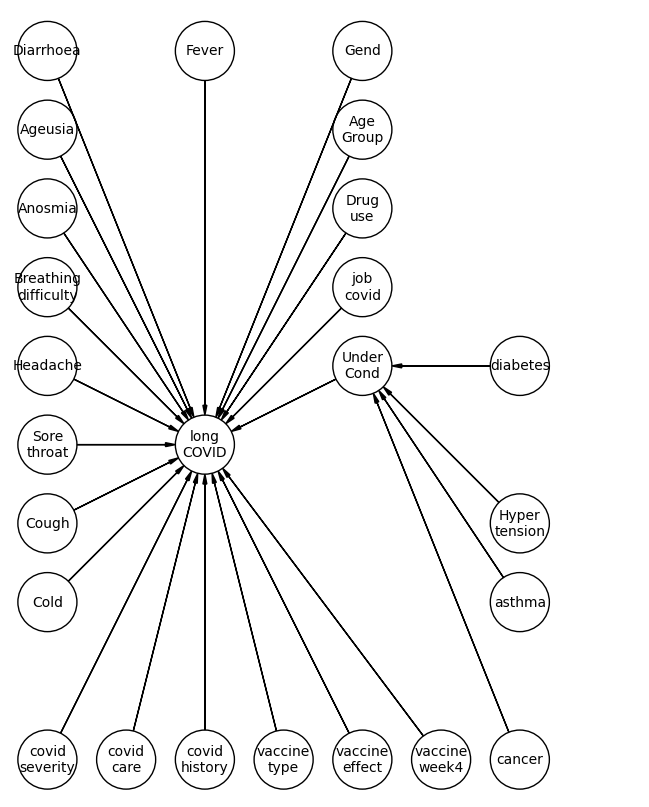

In [714]:
covidpgm.render()
plt.show()

In [715]:
longcovid_2.columns

Index(['longcovid_four', 'sex', 'occupation_covid', 'substance_use',
       'substance_use', 'covid_severity', 'covid_care', 'past_history_covid',
       'diabetes', 'hypertension', 'asthma', 'cancer', 'vaccine_type_four',
       'vaccine_dose_four', 'vaccine_aefi_four', 'Cold1', 'Cough',
       'Breathing difficulty', 'Sore throat', 'Headache1', 'Loss of smell',
       'Loss of taste', 'Fever', 'Diarrhoea1', 'Age_group', 'under_cond'],
      dtype='object')

In [716]:
longcovid_2.isna().sum()

longcovid_four          0
sex                     0
occupation_covid        0
substance_use           0
substance_use           0
covid_severity          0
covid_care              0
past_history_covid      0
diabetes                0
hypertension            0
asthma                  0
cancer                  0
vaccine_type_four       0
vaccine_dose_four       0
vaccine_aefi_four       0
Cold1                   0
Cough                   0
Breathing difficulty    0
Sore throat             0
Headache1               0
Loss of smell           0
Loss of taste           0
Fever                   0
Diarrhoea1              0
Age_group               0
under_cond              0
dtype: int64

In [717]:
longcovid_2=longcovid_1.loc[:,['longcovid_four', 'sex', 'occupation_covid',
                               #'substance_use', 
                               'covid_severity', 'covid_care', 'past_history_covid', 'diabetes', 
                               'hypertension', 'asthma', 'cancer', 'vaccine_dose_four','vaccine_type_four','vaccine_aefi_four','Cold1','Cough', 'Breathing difficulty', 'Sore throat',
                               'Headache1', 'Loss of smell', 'Loss of taste', 'Fever',
                               #'Diarrhoea1',
                               'Age_group','under_cond'
                              ]]


In [718]:
Hypercpd = TabularCPD(variable='hypertension',
                       variable_card=2,
                       values=[[0.34], [.66]]) #AIHW 34%
Diabcpd = TabularCPD(variable='diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%

cancercpd = TabularCPD(variable='cancer',
                       variable_card=2,
                       values=[[.43], [.57]]) #union from AIHW 19.6%



sexcpd = TabularCPD(variable='sex',
                       variable_card=2,
                       values=[[.5021], [.4979]]) #from ABS population
Agecpd = TabularCPD(variable='Age_group', #from ABS 
                       variable_card=4,
                       values=[ [.25], [0.25], [0.25], [0.25]])
#Subcpd = TabularCPD(variable='substance_use',
                       #variable_card=2,
                       #values=[[.042], [.958]]) #AIHW 11%



Coldcpd = TabularCPD(variable='Cold1',
                       variable_card=2,
                       values=[[.125], [.875]]) #20% on winters
Coughcpd = TabularCPD(variable='Cough',
                       variable_card=2,
                       values=[[.1], [.9]])
BDcpd = TabularCPD(variable='Breathing difficulty',
                       variable_card=2,
                       values=[[.075], [.925]])
Headachecpd = TabularCPD(variable='Headache1',
                       variable_card=2,
                       values=[[.15], [.85]])
Sorethroatcpd = TabularCPD(variable='Sore throat',
                       variable_card=2,
                       values=[[.1], [.90]])
Fevercpd = TabularCPD(variable='Fever',
                       variable_card=2,
                       values=[[.06], [.94]])
Anosmiacpd = TabularCPD(variable='Loss of smell',
                       variable_card=2,
                       values=[[.03], [.97]])

Ageusiacpd = TabularCPD(variable='Loss of taste',
                       variable_card=2,
                       values=[[.02], [.98]])

In [719]:
bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,cancercpd,sexcpd,Agecpd,
                 #Subcpd,
                 Coldcpd,Coughcpd,BDcpd,Headachecpd,Anosmiacpd,
Ageusiacpd,Fevercpd,Sorethroatcpd) 

In [720]:
training_data, testing_data = train_test_split(longcovid_2, test_size=0.35, random_state=42)

In [721]:
training_data.columns

Index(['longcovid_four', 'sex', 'occupation_covid', 'covid_severity',
       'covid_care', 'past_history_covid', 'diabetes', 'hypertension',
       'asthma', 'cancer', 'vaccine_dose_four', 'vaccine_type_four',
       'vaccine_aefi_four', 'Cold1', 'Cough', 'Breathing difficulty',
       'Sore throat', 'Headache1', 'Loss of smell', 'Loss of taste', 'Fever',
       'Age_group', 'under_cond'],
      dtype='object')

In [722]:
training_data.head(1)

,longcovid_four,sex,occupation_covid,covid_severity,covid_care,past_history_covid,diabetes,hypertension,asthma,cancer,vaccine_dose_four,vaccine_type_four,vaccine_aefi_four,Cold1,Cough,Breathing difficulty,Sore throat,Headache1,Loss of smell,Loss of taste,Fever,Age_group,under_cond
228,0,1,0,0,0,0,0,0,0,0,1,2,1.0,0,0,0,0,0,0,0,0,1,1


In [723]:
# Bayesian Estimation on the Training Data
estimator = BayesianEstimator(bnmodel, training_data)

long_covcpd = estimator.estimate_cpd('longcovid_four')
UCcpd = estimator.estimate_cpd('under_cond')

occucpd = estimator.estimate_cpd('occupation_covid')

cov_hiscpd = estimator.estimate_cpd('past_history_covid')
cov_sevcpd = estimator.estimate_cpd('covid_severity')
cov_carecpd = estimator.estimate_cpd('covid_care')


vacdose_4cpd = estimator.estimate_cpd('vaccine_dose_four')
vactype_4cpd=estimator.estimate_cpd('vaccine_type_four')
vaceff_4cpd=estimator.estimate_cpd('vaccine_aefi_four')

#Diarrcpd = estimator.estimate_cpd('Diarrhoea1')



bnmodel.add_cpds(long_covcpd,UCcpd,occucpd,cov_sevcpd,cov_carecpd,vacdose_4cpd,
                 #Diarrcpd,
                 cov_hiscpd,vactype_4cpd,vaceff_4cpd)

In [724]:
target = "longcovid_four"
features = longcovid_2.drop(columns=[target])
target =longcovid_1[target]

In [725]:
for node in bnmodel.nodes():
    # Get the variable corresponding to each node
    node_variable = bnmodel.get_cpds(node)
    
    # Get the state names for the node
    node_states = node_variable.state_names[node]
    
    # Print the node name and its states
    print(f"Node: {node}")
    print(f"States: {node_states}")

Node: Age_group
States: [0, 1, 2, 3]
Node: longcovid_four
States: [0, 1, 2]
Node: sex
States: [0, 1]
Node: occupation_covid
States: [0, 1]
Node: under_cond
States: [1]
Node: covid_severity
States: [0, 1, 2]
Node: covid_care
States: [0, 1]
Node: past_history_covid
States: [0, 1]
Node: diabetes
States: [0, 1]
Node: hypertension
States: [0, 1]
Node: asthma
States: [0, 1]
Node: cancer
States: [0, 1]
Node: vaccine_dose_four
States: [0, 1, 2]
Node: vaccine_type_four
States: [0, 1, 2]
Node: vaccine_aefi_four
States: [0.0, 1.0, 2.0]
Node: Cold1
States: [0, 1]
Node: Cough
States: [0, 1]
Node: Breathing difficulty
States: [0, 1]
Node: Sore throat
States: [0, 1]
Node: Headache1
States: [0, 1]
Node: Loss of smell
States: [0, 1]
Node: Loss of taste
States: [0, 1]
Node: Fever
States: [0, 1]


In [726]:
new_state_names = {0.0: 0, 1.0: 1, 2.0: 2}

# Update the state names for "vaccine_aefi_four" node in the Bayesian Network
bnmodel.get_cpds("vaccine_aefi_four").state_names["vaccine_aefi_four"] = list(new_state_names.values())

In [727]:
for node in bnmodel.nodes():
    # Get the variable corresponding to each node
    node_variable = bnmodel.get_cpds(node)
    
    # Get the state names for the node
    node_states = node_variable.state_names[node]
    
    # Print the node name and its states
    print(f"Node: {node}")
    print(f"States: {node_states}")

Node: Age_group
States: [0, 1, 2, 3]
Node: longcovid_four
States: [0, 1, 2]
Node: sex
States: [0, 1]
Node: occupation_covid
States: [0, 1]
Node: under_cond
States: [1]
Node: covid_severity
States: [0, 1, 2]
Node: covid_care
States: [0, 1]
Node: past_history_covid
States: [0, 1]
Node: diabetes
States: [0, 1]
Node: hypertension
States: [0, 1]
Node: asthma
States: [0, 1]
Node: cancer
States: [0, 1]
Node: vaccine_dose_four
States: [0, 1, 2]
Node: vaccine_type_four
States: [0, 1, 2]
Node: vaccine_aefi_four
States: [0, 1, 2]
Node: Cold1
States: [0, 1]
Node: Cough
States: [0, 1]
Node: Breathing difficulty
States: [0, 1]
Node: Sore throat
States: [0, 1]
Node: Headache1
States: [0, 1]
Node: Loss of smell
States: [0, 1]
Node: Loss of taste
States: [0, 1]
Node: Fever
States: [0, 1]


In [728]:
inference = VariableElimination(bnmodel)
is_valid = bnmodel.check_model()
if is_valid:
    print("The Bayesian network is valid.")
else:
    print("The Bayesian network contains errors.")

The Bayesian network is valid.


In [729]:
#infer=VariableElimination(bnmodel)
#evidence = {'Age_group': 3, 'Fever': 1, 'Cough': 1, 'vaccine_dose_four': 0, 'under_cond': 0, 'Cold1': 1}
 #0 is true
#print(infer.query(['longcovid_four'], evidence=evidence))

In [730]:
from pgmpy.inference import VariableElimination
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score
# Initialize VariableElimination once
inference = VariableElimination(bnmodel)

# Define the target variable
target = "longcovid_four"

# Define features as all columns except the target variable
features = longcovid_2.drop(columns=[target]).columns.tolist()

# Split the dataset into training and testing sets
X_test, y_test = testing_data[features], testing_data[target]

# Perform inference for all rows in X_test
predictions = []
for i in range(len(X_test)):
    evidence = X_test.iloc[i].to_dict()
    query = [target]
    factor = inference.query(variables=query, evidence=evidence)
    prediction = factor.values[2]  # Assuming you want the probability of 'longcovid_four' being 1
    predictions.append(prediction)
    
    
thresholds = [0.333, 0.666]

# Use list comprehension to categorize the values
categories = [0 if prediction < thresholds[0] else 1 if prediction < thresholds[1] else 2 for prediction in predictions]
accuracy = accuracy_score(y_test, categories)


cm = confusion_matrix(y_test, categories)
print(cm)
print(accuracy)

[[60 63  0]
 [13 32  0]
 [ 1  2  0]]
0.5380116959064327


In [731]:
longcovid_2['longcovid_four'].unique()

array([0, 1, 2])

In [752]:
bnmodel2=BayesianNetwork([
#background(6)
('Age_group','longcovid_four'),('sex','longcovid_four'),( 'occupation_covid','longcovid_four')
,('under_cond','longcovid_four'),
#,('substance_use','longcovid_four'),
#covid(3)
('covid_severity','covid_care'),('covid_care','longcovid_four'),('past_history_covid','longcovid_four'),
#medical conditions(6)
('diabetes','under_cond'),('hypertension','under_cond'),
('asthma','under_cond'),('cancer','under_cond'),
#vaccine(3)
('vaccine_type_four','vaccine_aefi_four'),('vaccine_dose_four','longcovid_four'),('vaccine_aefi_four','longcovid_four'),
#symptoms(10)
('Cold1','longcovid_four'),('Cough','longcovid_four'),('Breathing difficulty','longcovid_four'),
('Sore throat','longcovid_four'),('Headache1','longcovid_four'),('Loss of smell','longcovid_four'),('Loss of taste','longcovid_four')
,('Fever','longcovid_four')
#,('Diarrhoea1','longcovid_four')   
])

In [753]:
Hypercpd = TabularCPD(variable='hypertension',
                       variable_card=2,
                       values=[[0.34], [.66]]) #AIHW 34%
Diabcpd = TabularCPD(variable='diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%

cancercpd = TabularCPD(variable='cancer',
                       variable_card=2,
                       values=[[.43], [.57]]) #union from AIHW 19.6%



sexcpd = TabularCPD(variable='sex',
                       variable_card=2,
                       values=[[.5021], [.4979]]) #from ABS population
Agecpd = TabularCPD(variable='Age_group', #from ABS 
                       variable_card=4,
                       values=[ [.25], [0.25], [0.25], [0.25]])
#Subcpd = TabularCPD(variable='substance_use',
                       #variable_card=2,
                       #values=[[.042], [.958]]) #AIHW 11%



Coldcpd = TabularCPD(variable='Cold1',
                       variable_card=2,
                       values=[[.125], [.875]]) #20% on winters
Coughcpd = TabularCPD(variable='Cough',
                       variable_card=2,
                       values=[[.1], [.9]])
BDcpd = TabularCPD(variable='Breathing difficulty',
                       variable_card=2,
                       values=[[.075], [.925]])
Headachecpd = TabularCPD(variable='Headache1',
                       variable_card=2,
                       values=[[.15], [.85]])
Sorethroatcpd = TabularCPD(variable='Sore throat',
                       variable_card=2,
                       values=[[.1], [.90]])
Fevercpd = TabularCPD(variable='Fever',
                       variable_card=2,
                       values=[[.06], [.94]])
Anosmiacpd = TabularCPD(variable='Loss of smell',
                       variable_card=2,
                       values=[[.03], [.97]])

Ageusiacpd = TabularCPD(variable='Loss of taste',
                       variable_card=2,
                       values=[[.02], [.98]])


bnmodel2.add_cpds(Hypercpd,Diabcpd,Asthmacpd,cancercpd,sexcpd,Agecpd,
                 #Subcpd,
                 Coldcpd,Coughcpd,BDcpd,Headachecpd,Anosmiacpd,
Ageusiacpd,Fevercpd,Sorethroatcpd) 

In [754]:
training_data, testing_data = train_test_split(longcovid_2, test_size=0.35)

In [755]:
# Bayesian Estimation on the Training Data
estimator = BayesianEstimator(bnmodel2, training_data)

long_covcpd = estimator.estimate_cpd('longcovid_four')
UCcpd = estimator.estimate_cpd('under_cond')

occucpd = estimator.estimate_cpd('occupation_covid')

cov_hiscpd = estimator.estimate_cpd('past_history_covid')
cov_sevcpd = estimator.estimate_cpd('covid_severity')
cov_carecpd = estimator.estimate_cpd('covid_care')


vacdose_4cpd = estimator.estimate_cpd('vaccine_dose_four')
vactype_4cpd=estimator.estimate_cpd('vaccine_type_four')
vaceff_4cpd=estimator.estimate_cpd('vaccine_aefi_four')

#Diarrcpd = estimator.estimate_cpd('Diarrhoea1')



bnmodel2.add_cpds(long_covcpd,UCcpd,occucpd,cov_sevcpd,cov_carecpd,vacdose_4cpd,
                 #Diarrcpd,
                 cov_hiscpd,vactype_4cpd,vaceff_4cpd)

In [756]:
target = "longcovid_four"
features = longcovid_2.drop(columns=[target])
target =longcovid_1[target]

In [757]:
for node in bnmodel.nodes():
    # Get the variable corresponding to each node
    node_variable = bnmodel.get_cpds(node)
    
    # Get the state names for the node
    node_states = node_variable.state_names[node]
    
    # Print the node name and its states
    print(f"Node: {node}")
    print(f"States: {node_states}")

Node: Age_group
States: [0, 1, 2, 3]
Node: longcovid_four
States: [0, 1, 2]
Node: sex
States: [0, 1]
Node: occupation_covid
States: [0, 1]
Node: under_cond
States: [1]
Node: covid_severity
States: [0, 1, 2]
Node: covid_care
States: [0, 1]
Node: past_history_covid
States: [0, 1]
Node: diabetes
States: [0, 1]
Node: hypertension
States: [0, 1]
Node: asthma
States: [0, 1]
Node: cancer
States: [0, 1]
Node: vaccine_dose_four
States: [0, 1, 2]
Node: vaccine_type_four
States: [0, 1, 2]
Node: vaccine_aefi_four
States: [0.0, 1.0, 2.0]
Node: Cold1
States: [0, 1]
Node: Cough
States: [0, 1]
Node: Breathing difficulty
States: [0, 1]
Node: Sore throat
States: [0, 1]
Node: Headache1
States: [0, 1]
Node: Loss of smell
States: [0, 1]
Node: Loss of taste
States: [0, 1]
Node: Fever
States: [0, 1]


In [758]:
new_state_names = {0.0: 0, 1.0:1, 2.0:2}

# Update the state names for "vaccine_aefi_four" node in the Bayesian Network
bnmodel2.get_cpds("vaccine_aefi_four").state_names["vaccine_aefi_four"] = list(new_state_names.values())

In [760]:
inference = VariableElimination(bnmodel2)
is_valid = bnmodel2.check_model()
if is_valid:
    print("The Bayesian network is valid.")
else:
    print("The Bayesian network contains errors.")

The Bayesian network is valid.


In [764]:
from pgmpy.inference import VariableElimination
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score
# Initialize VariableElimination once
inference = VariableElimination(bnmodel2)

# Define the target variable
target = "longcovid_four"

# Define features as all columns except the target variable
features = longcovid_2.drop(columns=[target]).columns.tolist()

# Split the dataset into training and testing sets
X_test, y_test = testing_data[features], testing_data[target]

# Perform inference for all rows in X_test
predictions = []
for i in range(len(X_test)):
    evidence = X_test.iloc[i].to_dict()
    query = [target]
    factor = inference.query(variables=query, evidence=evidence)
    prediction = factor.values[2]  # Assuming you want the probability of 'longcovid_four' being 1
    predictions.append(prediction)
    
    
thresholds = [0.333, 0.666]


categories = [0 if prediction < thresholds[0] else 1 if prediction < thresholds[1] else 2 for prediction in predictions]
accuracy = accuracy_score(y_test, categories)


cm = confusion_matrix(y_test, categories)
print(cm)
print(accuracy)

[[68 47  0]
 [21 29  0]
 [ 2  4  0]]
0.5672514619883041
